In [29]:
import json
import pandas as pd
import psycopg2
from psycopg2.extras import execute_values
import plotly.express as px
import dash
from dash import dcc, html, dash_table
from dash.dependencies import Input, Output

In [30]:
JSON_FILE = "/home/ubuntu/Desktop/Assignment Resources/CS 590 Project Datasets/CS 590 Project Dataset #1.json"

DB_CONFIG = {
    "host": "localhost",
    "database": "postgres",
    "user": "postgres",
    "password": "Codio590"
}

In [31]:
with open(JSON_FILE, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

print(raw_data.keys())
print(raw_data["metadata"])
print("Number of features:", len(raw_data["features"]))

dict_keys(['type', 'metadata', 'features', 'bbox'])
{'generated': 1744731952000, 'url': 'https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/1.0_month.geojson', 'title': 'USGS Magnitude 1.0+ Earthquakes, Past Month', 'status': 200, 'api': '1.14.1', 'count': 6701}
Number of features: 6701


In [32]:
metadata = raw_data["metadata"]

metadata_df = pd.DataFrame([{
    "generated_at": pd.to_datetime(metadata.get("generated"), unit="ms", utc=True),
    "source_url": metadata.get("url"),
    "title": metadata.get("title"),
    "status_code": metadata.get("status"),
    "api_version": metadata.get("api"),
    "record_count": metadata.get("count")
}])

records = []

for feature in raw_data["features"]:
    props = feature.get("properties", {})
    geom = feature.get("geometry", {})
    coords = geom.get("coordinates", [None, None, None])

    records.append({
        "earthquake_id": feature.get("id"),
        "magnitude": props.get("mag"),
        "place_description": props.get("place"),
        "event_time": pd.to_datetime(props.get("time"), unit="ms", utc=True),
        "updated_time": pd.to_datetime(props.get("updated"), unit="ms", utc=True),
        "felt_reports": props.get("felt"),
        "cdi": props.get("cdi"),
        "mmi": props.get("mmi"),
        "alert_level": props.get("alert"),
        "review_status": props.get("status"),
        "tsunami": props.get("tsunami"),
        "significance": props.get("sig"),
        "network_code": props.get("net"),
        "event_code": props.get("code"),
        "nst": props.get("nst"),
        "dmin": props.get("dmin"),
        "rms": props.get("rms"),
        "gap": props.get("gap"),
        "mag_type": props.get("magType"),
        "event_type": props.get("type"),
        "title": props.get("title"),
        "detail_url": props.get("detail"),
        "event_url": props.get("url"),
        "longitude": coords[0],
        "latitude": coords[1],
        "depth_km": coords[2]
    })

eq_df = pd.DataFrame(records)

print(metadata_df.head())
print(eq_df.head())
print(eq_df.shape)

               generated_at  \
0 2025-04-15 15:45:52+00:00   

                                          source_url  \
0  https://earthquake.usgs.gov/earthquakes/feed/v...   

                                         title  status_code api_version  \
0  USGS Magnitude 1.0+ Earthquakes, Past Month          200      1.14.1   

   record_count  
0          6701  
  earthquake_id  magnitude                     place_description  \
0  ak0254twm1q3        1.2          30 km W of Salamatof, Alaska   
1  ak0254tw2r6v        1.6      16 km SSW of Petersville, Alaska   
2    tx2025hjdt        2.0    57 km S of Whites City, New Mexico   
3  ak0254tw0l7z        2.0    8 km W of Point Possession, Alaska   
4    tx2025hjdm        2.0  52 km SSE of Whites City, New Mexico   

                        event_time                     updated_time  \
0 2025-04-15 15:42:48.274000+00:00 2025-04-15 15:44:52.381000+00:00   
1 2025-04-15 14:52:47.118000+00:00 2025-04-15 14:55:11.157000+00:00   
2 2025-04-15 14

In [33]:
eq_df["place_description"] = eq_df["place_description"].fillna("Unknown")
eq_df["alert_level"] = eq_df["alert_level"].fillna("none")
eq_df["review_status"] = eq_df["review_status"].fillna("unknown")
eq_df["mag_type"] = eq_df["mag_type"].fillna("unknown")
eq_df["event_type"] = eq_df["event_type"].fillna("unknown")
eq_df["tsunami"] = eq_df["tsunami"].fillna(0).astype(int)

numeric_cols = [
    "magnitude", "felt_reports", "cdi", "mmi", "significance",
    "nst", "dmin", "rms", "gap", "longitude", "latitude", "depth_km"
]

for col in numeric_cols:
    eq_df[col] = pd.to_numeric(eq_df[col], errors="coerce")

eq_df["event_date"] = eq_df["event_time"].dt.date
eq_df["event_hour"] = eq_df["event_time"].dt.hour

print(eq_df.dtypes)
print(eq_df.isnull().sum())

earthquake_id                     object
magnitude                        float64
place_description                 object
event_time           datetime64[ns, UTC]
updated_time         datetime64[ns, UTC]
felt_reports                     float64
cdi                              float64
mmi                              float64
alert_level                       object
review_status                     object
tsunami                            int64
significance                       int64
network_code                      object
event_code                        object
nst                              float64
dmin                             float64
rms                              float64
gap                              float64
mag_type                          object
event_type                        object
title                             object
detail_url                        object
event_url                         object
longitude                        float64
latitude        

In [34]:
conn = psycopg2.connect(
    host=DB_CONFIG["host"],
    database=DB_CONFIG["database"],
    user=DB_CONFIG["user"],
    password=DB_CONFIG["password"]
)
conn.autocommit = False
cur = conn.cursor()

print("Connected successfully.")

Connected successfully.


In [35]:
cur.execute("DELETE FROM cs590_project.earthquakes;")
cur.execute("DELETE FROM cs590_project.locations;")
cur.execute("DELETE FROM cs590_project.feed_metadata;")

metadata_insert_sql = """
    INSERT INTO cs590_project.feed_metadata (
        generated_at, source_url, title, status_code, api_version, record_count
    )
    VALUES (%s, %s, %s, %s, %s, %s)
    RETURNING metadata_id;
"""

cur.execute(metadata_insert_sql, (
    metadata_df.loc[0, "generated_at"].to_pydatetime(),
    metadata_df.loc[0, "source_url"],
    metadata_df.loc[0, "title"],
    int(metadata_df.loc[0, "status_code"]),
    metadata_df.loc[0, "api_version"],
    int(metadata_df.loc[0, "record_count"])
))

metadata_id = cur.fetchone()[0]
print("metadata_id:", metadata_id)

metadata_id: 3


In [36]:
locations_df = eq_df[["place_description", "latitude", "longitude", "depth_km"]].drop_duplicates().reset_index(drop=True)

location_insert_sql = """
    INSERT INTO cs590_project.locations (place_description, latitude, longitude, depth_km)
    VALUES %s
    ON CONFLICT (place_description, latitude, longitude, depth_km) DO NOTHING;
"""

location_tuples = [tuple(x) for x in locations_df.to_numpy()]
execute_values(cur, location_insert_sql, location_tuples)

cur.execute("""
    SELECT location_id, place_description, latitude, longitude, depth_km
    FROM cs590_project.locations;
""")

location_map_df = pd.DataFrame(
    cur.fetchall(),
    columns=["location_id", "place_description", "latitude", "longitude", "depth_km"]
)

eq_df = eq_df.merge(
    location_map_df,
    on=["place_description", "latitude", "longitude", "depth_km"],
    how="left"
)

print(eq_df[["earthquake_id", "location_id"]].head())
print("Unique locations loaded:", len(location_map_df))

  earthquake_id  location_id
0  ak0254twm1q3        13397
1  ak0254tw2r6v        13398
2    tx2025hjdt        13399
3  ak0254tw0l7z        13400
4    tx2025hjdm        13401
Unique locations loaded: 6698


In [37]:
earthquake_insert_sql = """
    INSERT INTO cs590_project.earthquakes (
        earthquake_id, metadata_id, location_id, magnitude, event_time, updated_time,
        felt_reports, cdi, mmi, alert_level, review_status, tsunami, significance,
        network_code, event_code, nst, dmin, rms, gap, mag_type, event_type, title,
        detail_url, event_url
    )
    VALUES %s
    ON CONFLICT (earthquake_id) DO NOTHING;
"""

earthquake_tuples = []
for _, row in eq_df.iterrows():
    earthquake_tuples.append((
        row["earthquake_id"],
        metadata_id,
        int(row["location_id"]) if pd.notnull(row["location_id"]) else None,
        row["magnitude"],
        row["event_time"].to_pydatetime() if pd.notnull(row["event_time"]) else None,
        row["updated_time"].to_pydatetime() if pd.notnull(row["updated_time"]) else None,
        int(row["felt_reports"]) if pd.notnull(row["felt_reports"]) else None,
        row["cdi"],
        row["mmi"],
        row["alert_level"],
        row["review_status"],
        int(row["tsunami"]) if pd.notnull(row["tsunami"]) else 0,
        int(row["significance"]) if pd.notnull(row["significance"]) else None,
        row["network_code"],
        row["event_code"],
        int(row["nst"]) if pd.notnull(row["nst"]) else None,
        row["dmin"],
        row["rms"],
        row["gap"],
        row["mag_type"],
        row["event_type"],
        row["title"],
        row["detail_url"],
        row["event_url"]
    ))

execute_values(cur, earthquake_insert_sql, earthquake_tuples, page_size=1000)
conn.commit()

print("Data inserted successfully.")
print("Earthquake rows prepared:", len(earthquake_tuples))

Data inserted successfully.
Earthquake rows prepared: 6701


In [38]:
validation_queries = {
    "metadata_count": "SELECT COUNT(*) FROM cs590_project.feed_metadata;",
    "location_count": "SELECT COUNT(*) FROM cs590_project.locations;",
    "earthquake_count": "SELECT COUNT(*) FROM cs590_project.earthquakes;",
    "top_5_magnitudes": """
        SELECT earthquake_id, magnitude, title
        FROM cs590_project.earthquakes
        ORDER BY magnitude DESC
        LIMIT 5;
    """,
    "tsunami_events": """
        SELECT COUNT(*)
        FROM cs590_project.earthquakes
        WHERE tsunami = 1;
    """,
    "red_alert_events": """
        SELECT COUNT(*)
        FROM cs590_project.earthquakes
        WHERE alert_level = 'red';
    """
}

for label, query in validation_queries.items():
    cur.execute(query)
    print("\n" + label)
    print(cur.fetchall())


metadata_count
[(1,)]

location_count
[(6698,)]

earthquake_count
[(6701,)]

top_5_magnitudes
[('us7000pn9s', 7.7, 'M 7.7 - 2025 Mandalay, Burma (Myanmar) Earthquake'), ('us7000pntq', 7.0, 'M 7.0 - 73 km SE of Pangai, Tonga'), ('us6000q41n', 6.9, 'M 6.9 - 181 km ESE of Kimbe, Papua New Guinea'), ('us6000q3nw', 6.9, 'M 6.9 - Reykjanes Ridge'), ('us7000pn9z', 6.7, 'M 6.7 - Burma (Myanmar)')]

tsunami_events
[(13,)]

red_alert_events
[(1,)]


In [39]:
dashboard_query = """
SELECT
    e.earthquake_id,
    e.magnitude,
    e.event_time,
    e.alert_level,
    e.tsunami,
    e.significance,
    l.place_description,
    l.latitude,
    l.longitude,
    l.depth_km
FROM cs590_project.earthquakes e
JOIN cs590_project.locations l
ON e.location_id = l.location_id;
"""

dashboard_df = pd.read_sql(dashboard_query, conn)

dashboard_df["event_time"] = pd.to_datetime(dashboard_df["event_time"])
dashboard_df["event_date"] = dashboard_df["event_time"].dt.date

print(dashboard_df.shape)
dashboard_df.head()

(6701, 11)


/tmp/ipykernel_3127/1952800184.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dashboard_df = pd.read_sql(dashboard_query, conn)


,earthquake_id,magnitude,event_time,alert_level,tsunami,significance,place_description,latitude,longitude,depth_km,event_date
0,ak0254twm1q3,1.2,2025-04-15 15:42:48.274000+00:00,none,0,22,"30 km W of Salamatof, Alaska",60.5778,-151.8745,76.2000,2025-04-15
1,ak0254tw2r6v,1.6,2025-04-15 14:52:47.118000+00:00,none,0,39,"16 km SSW of Petersville, Alaska",62.3533,-150.8596,68.7000,2025-04-15
2,tx2025hjdt,2.0,2025-04-15 14:51:49.556000+00:00,none,0,62,"57 km S of Whites City, New Mexico",31.6590,-104.3320,6.6382,2025-04-15
3,ak0254tw0l7z,2.0,2025-04-15 14:42:36.637000+00:00,none,0,62,"8 km W of Point Possession, Alaska",60.9372,-150.8376,16.3000,2025-04-15
4,tx2025hjdm,2.0,2025-04-15 14:42:13.905000+00:00,none,0,62,"52 km SSE of Whites City, New Mexico",31.7150,-104.2680,6.7664,2025-04-15


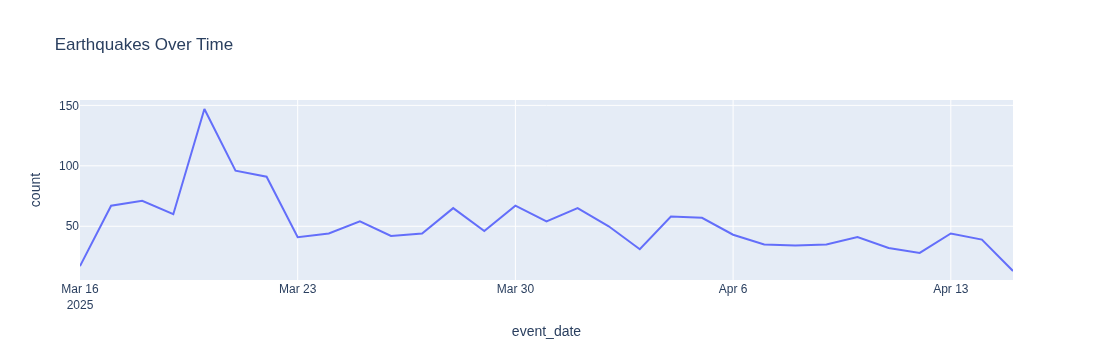

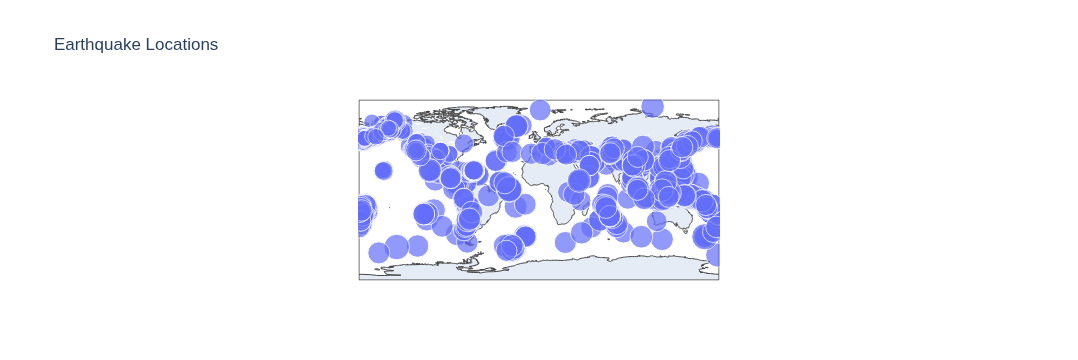

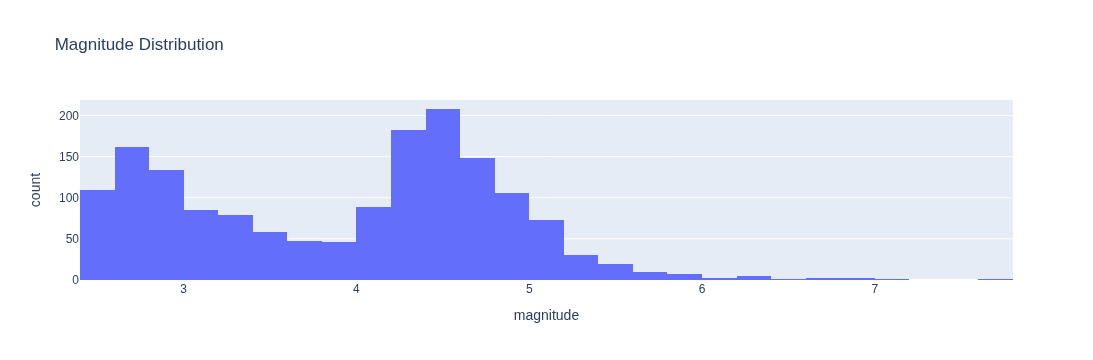

In [41]:
filtered_df = dashboard_df[dashboard_df["magnitude"] >= 2.5]

daily_counts = filtered_df.groupby("event_date").size().reset_index(name="count")

px.line(daily_counts, x="event_date", y="count", title="Earthquakes Over Time").show()

px.scatter_geo(
    filtered_df,
    lat="latitude",
    lon="longitude",
    size="magnitude",
    title="Earthquake Locations"
).show()

px.histogram(filtered_df, x="magnitude", nbins=30, title="Magnitude Distribution").show()